In [ ]:
!pip install datasets evaluate transformers[sentencepiece]
!pip install accelerate±±
# To run the training on TPU, you will need to uncomment the following line:
 #!pip install cloud-tpu-client==0.10 torch==1.9.0 https://storage.googleapis.com/tpu-pytorch/wheels/torch_xla-1.9-cp37-cp37m-linux_x86_64.whl
!apt install git-lfs

ERROR: Invalid requirement: 'accelerate±±': Expected end or semicolon (after name and no valid version specifier)
    accelerate±±
              ^
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:
!pip install evaluate
!pip install rouge_score

In [ ]:
from datasets import load_dataset

In [ ]:
ds = load_dataset("dnagpt/kaggle_amazon_reviews_multi")
print(ds.keys())

#print(ds['train'][0])  # Check the first row of the training dataset
#print(ds['train'][:5])  # View the first 5 rows

print(f"Train size: {len(ds['train'])}")
print(f"Validation size: {len(ds['validation'])}")
print(f"Test size: {len(ds['test'])}")


print(ds['train'].column_names)  # For the training split




dict_keys(['train', 'test', 'validation'])
Train size: 1200000
Validation size: 30000
Test size: 30000
['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category']


In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
        num_rows: 1200000
    })
    test: Dataset({
        features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
        num_rows: 30000
    })
    validation: Dataset({
        features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
        num_rows: 30000
    })
})

In [ ]:
languages=set(ds["train"]["language"])
num_languages=len(languages)
print(languages)
print(num_languages)


{'en', 'de', 'ja', 'zh', 'es', 'fr'}
6


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
def show_samples(ds, num_samples=3, seed=42):
    sample = ds.shuffle(seed=seed).select(range(num_samples))
    for example in sample:
        print(f"\n'>> Language: {example['language']}'")
        print(f"'>> Title: {example['review_title']}'")
        print(f"'>> Review: {example['review_body']}'")


show_samples(ds["train"])



'>> Language: es'
'>> Title: Me ha gustado mucho'
'>> Review: La verdad es que estoy muy contenta con él. Está muy bien distribuido tiene monedero de botón y de cremallera y puedo poner todas mis tarjetas más dos compartimentos para billetes. Y luego con la correa para que no se caiga ninguna tarjeta y que cierra completamente el monedero es ideal.Ahora, solo esperar que dure .'

'>> Language: de'
'>> Title: Naja'
'>> Review: Die Hülle ist eigentlich sehr schön und passt perfekt. Aber leider nutzt sie sich schnell ab und an den Ecken geht die Farbe ab. Das sieht sehr unschön aus. Erfüllt aber trotzdem ihr Zweck'

'>> Language: de'
'>> Title: Rapunzel Puppe'
'>> Review: Rapunzel bestellt. 1 Tag später war die Strähnen kaputt und hat nimmer geleuchtet. Dann haben wir Ersatz bestellt. Rapunzel hat genau einen Tag geleuchtet wieder kaputt. Habe beide zurück geschickt und der Witz man bekommt nur ein Anteil zurück vom Verand.'


In [ ]:
# Create a dictionary to store each language dataset
language_datasets = {}

# Loop through all available languages
for lang in languages:
    # Filter each split (train, test, validation)
    train_split = ds["train"].filter(lambda x: x["language"] == lang)
    test_split = ds["test"].filter(lambda x: x["language"] == lang)
    val_split = ds["validation"].filter(lambda x: x["language"] == lang)

    # Combine into a DatasetDict
    language_datasets[lang] = {
        "train": train_split,
        "test": test_split,
        "validation": val_split
    }

    print(f"✅ {lang} → Train: {len(train_split)} | Test: {len(test_split)} | Val: {len(val_split)}")


✅ en → Train: 200000 | Test: 5000 | Val: 5000
✅ de → Train: 200000 | Test: 5000 | Val: 5000
✅ ja → Train: 200000 | Test: 5000 | Val: 5000
✅ zh → Train: 200000 | Test: 5000 | Val: 5000
✅ es → Train: 200000 | Test: 5000 | Val: 5000
✅ fr → Train: 200000 | Test: 5000 | Val: 5000


In [ ]:
language_datasets

{'en': {'train': Dataset({
      features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
      num_rows: 200000
  }),
  'test': Dataset({
      features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
      num_rows: 5000
  }),
  'validation': Dataset({
      features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
      num_rows: 5000
  })},
 'de': {'train': Dataset({
      features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
      num_rows: 200000
  }),
  'test': Dataset({
      features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
      num_rows: 5000
  }),
  'validat

In [ ]:
english_ds=language_datasets["en"]
spanish_ds=language_datasets["es"]
french_ds=language_datasets["fr"]
japanese_ds=language_datasets["ja"]
chinese_ds=language_datasets["zh"]
german_ds=language_datasets["de"]

In [ ]:
show_samples(english_ds["train"])


'>> Language: en'
'>> Title: Worked in front position, not rear'
'>> Review: 3 stars because these are not rear brakes as stated in the item description. At least the mount adapter only worked on the front fork of the bike that I got it for.'

'>> Language: en'
'>> Title: meh'
'>> Review: Does it’s job and it’s gorgeous but mine is falling apart, I had to basically put it together again with hot glue'

'>> Language: en'
'>> Title: Can't beat these for the money'
'>> Review: Bought this for handling miscellaneous aircraft parts and hanger "stuff" that I needed to organize; it really fit the bill. The unit arrived quickly, was well packaged and arrived intact (always a good sign). There are five wall mounts-- three on the top and two on the bottom. I wanted to mount it on the wall, so all I had to do was to remove the top two layers of plastic drawers, as well as the bottom corner drawers, place it when I wanted and mark it; I then used some of the new plastic screw in wall anchors (the

In [ ]:
english_ds

{'train': Dataset({
     features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
     num_rows: 200000
 }),
 'test': Dataset({
     features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
     num_rows: 5000
 }),
 'validation': Dataset({
     features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
     num_rows: 5000
 })}

In [ ]:
english_ds["train"].set_format("pandas")
en_df = english_ds["train"][:]
# Show counts for top 20 products
en_df["product_category"].value_counts()[:20]

,count
product_category,
home,17679
apparel,15951
wireless,15717
other,13418
beauty,12091
drugstore,11730
kitchen,10382
toy,8745
sports,8277


In [ ]:

def filter_books(example):
    return (
        example["product_category"] == "book"
        or example["product_category"] == "digital_ebook_purchase"
    )

# reset_format on each split (if needed)
for split in english_ds:
    english_ds[split].reset_format()
for split in spanish_ds:
    spanish_ds[split].reset_format()

# Filter every split in both datasets
english_books = {split: ds.filter(filter_books) for split, ds in english_ds.items()}
spanish_books = {split: ds.filter(filter_books) for split, ds in spanish_ds.items()}

# Check sizes to confirm filtering worked
for split in english_books:
    print(f"English {split} size:", len(english_books[split]))
for split in spanish_books:
    print(f"Spanish {split} size:", len(spanish_books[split]))


English train size: 10505
English test size: 278
English validation size: 231
Spanish train size: 7107
Spanish test size: 164
Spanish validation size: 193


In [ ]:
english_books

{'train': Dataset({
     features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
     num_rows: 10505
 }),
 'test': Dataset({
     features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
     num_rows: 278
 }),
 'validation': Dataset({
     features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
     num_rows: 231
 })}

In [ ]:

from datasets import concatenate_datasets, DatasetDict

books_dataset = DatasetDict()

for split in english_books.keys():
    books_dataset[split] = concatenate_datasets(
        [english_books[split], spanish_books[split]]
    )
    books_dataset[split] = books_dataset[split].shuffle(seed=42)

# Peek at a few examples
show_samples(books_dataset["train"])


'>> Language: en'
'>> Title: Easy to follow!!!!'
'>> Review: I loved The dash diet weight loss Solution. Never hungry. I would recommend this diet. Also the menus are well rounded. Try it. Has lots of the information need thanks.'

'>> Language: es'
'>> Title: PARCIALMENTE DAÑADO'
'>> Review: Me llegó el día que tocaba, junto a otros libros que pedí, pero la caja llegó en mal estado lo cual dañó las esquinas de los libros porque venían sin protección (forro).'

'>> Language: es'
'>> Title: no lo he podido descargar'
'>> Review: igual que el anterior'


In [ ]:
books_dataset

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
        num_rows: 17612
    })
    test: Dataset({
        features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
        num_rows: 442
    })
    validation: Dataset({
        features: ['Unnamed: 0', 'review_id', 'product_id', 'reviewer_id', 'stars', 'review_body', 'review_title', 'language', 'product_category'],
        num_rows: 424
    })
})

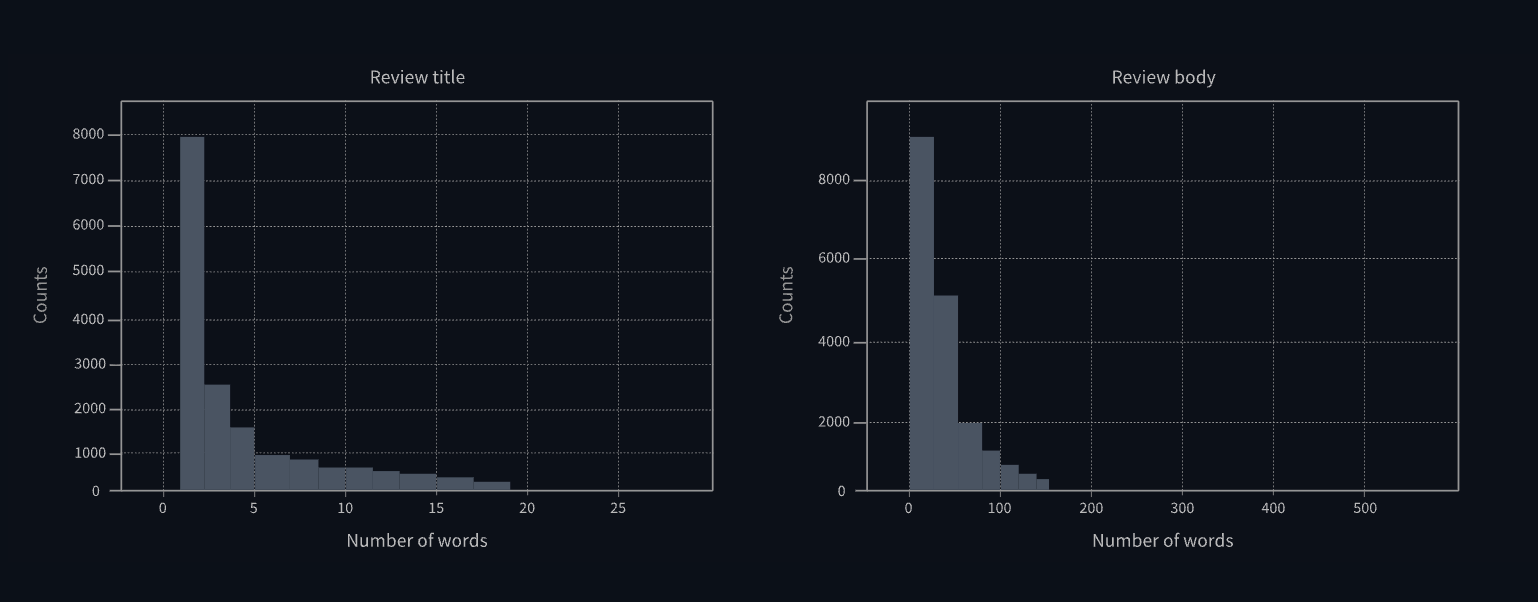

In [ ]:
#we filter the short reviews
books_dataset = books_dataset.filter(lambda x: len(x["review_title"].split()) > 2)

The mT5 model is a sequence-to-sequence Transformer designed to take text as input and produce text as output, regardless of language or task.
Its purpose is to provide a unified architecture for all NLP tasks — translation, summarization, question answering, etc. — by training a single encoder–decoder Transformer that learns to model the mapping between input and output text.

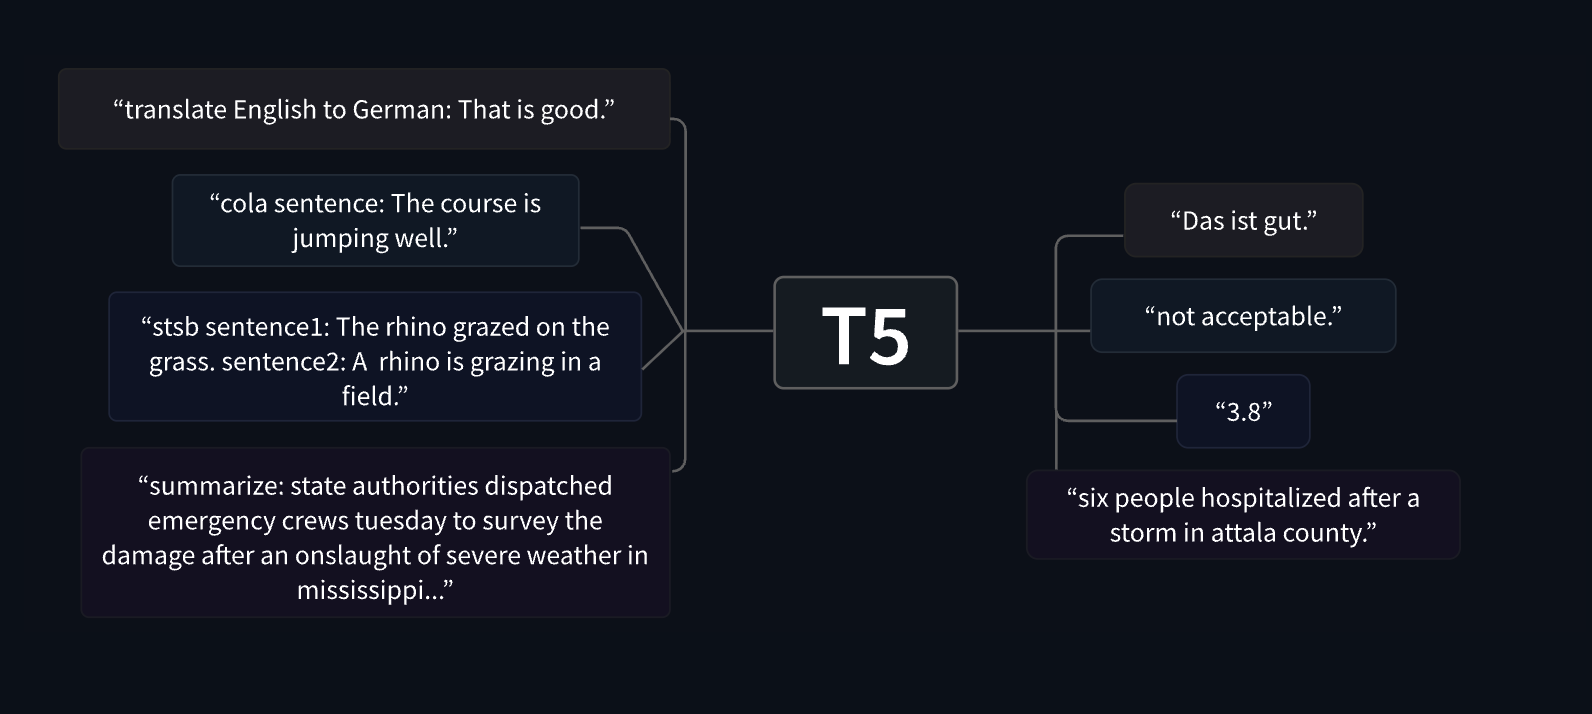

Our next task is to tokenize and encode our reviews and their titles. As usual, we begin by loading the tokenizer associated with the pretrained model checkpoint. We’ll use mt5-small as our checkpoint so we can fine-tune the model in a reasonable amount of time:

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_checkpoint = "google/mt5-small"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, use_fast=False)

In [ ]:
inputs = tokenizer("I loved reading the Hunger Games!")
print(inputs)
tokenizer.convert_ids_to_tokens(inputs.input_ids)

{'input_ids': [336, 259, 28387, 11807, 287, 62893, 295, 12507, 309, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


['▁I', '▁', 'loved', '▁reading', '▁the', '▁Hung', 'er', '▁Games', '!', '</s>']

In [ ]:
max_input_length = 512
max_target_length = 30


def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["review_body"],
        max_length=max_input_length,
        truncation=True,
    )
    labels = tokenizer(
        examples["review_title"], max_length=max_target_length, truncation=True
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

max_input_length and max_target_length, which set the upper limits for how long our reviews and titles can be. Since the review body is typically much larger than the title, we’ve scaled these values accordingly.



In [ ]:
tokenized_datasets = books_dataset.map(preprocess_function, batched=True)

In [ ]:
#FIX ======

# --- Fix for negative token IDs ---
def remove_negative_tokens(batch):
    # Ensure all input_ids are non-negative
    batch["input_ids"] = [[max(0, token) for token in ids] for ids in batch["input_ids"]]

    # Do the same for labels (if present)
    if "labels" in batch:
        batch["labels"] = [[max(0, token) for token in ids] for ids in batch["labels"]]

    return batch

# Apply fix to the entire dataset
tokenized_datasets = tokenized_datasets.map(remove_negative_tokens, batched=True)

print("✅ Negative token IDs removed successfully!")


Map:   0%|          | 0/9672 [00:00<?, ? examples/s]

Map:   0%|          | 0/245 [00:00<?, ? examples/s]

Map:   0%|          | 0/238 [00:00<?, ? examples/s]

✅ Negative token IDs removed successfully!


For summarization, one of the most commonly used metrics is the ROUGE score (short for Recall-Oriented Understudy for Gisting Evaluation). The basic idea behind this metric is to compare a generated summary against a set of reference summaries that are typically created by humans. To make this more precise, suppose we want to compare the following two summaries:

In [ ]:
generated_summary = "I absolutely loved reading the Hunger Games"
reference_summary = "I loved reading the Hunger Games"

In [ ]:
import numpy as np
np.set_printoptions(legacy='1.13')  # affects NumPy print style


In [ ]:
import evaluate
rouge_score = evaluate.load("rouge")

from collections import namedtuple

rouge = evaluate.load("rouge")
res = rouge.compute(predictions=[generated_summary], references=[reference_summary])

Score = namedtuple("Score", ["precision", "recall", "fmeasure"])
AggregateScore = namedtuple("AggregateScore", ["low", "mid", "high"])

scores = {k: AggregateScore(Score(v,1.0,v), Score(v,1.0,v), Score(v,1.0,v)) for k,v in res.items()}
print(scores)





{'rouge1': AggregateScore(low=Score(precision=0.92307692307692302, recall=1.0, fmeasure=0.92307692307692302), mid=Score(precision=0.92307692307692302, recall=1.0, fmeasure=0.92307692307692302), high=Score(precision=0.92307692307692302, recall=1.0, fmeasure=0.92307692307692302)), 'rouge2': AggregateScore(low=Score(precision=0.72727272727272718, recall=1.0, fmeasure=0.72727272727272718), mid=Score(precision=0.72727272727272718, recall=1.0, fmeasure=0.72727272727272718), high=Score(precision=0.72727272727272718, recall=1.0, fmeasure=0.72727272727272718)), 'rougeL': AggregateScore(low=Score(precision=0.92307692307692302, recall=1.0, fmeasure=0.92307692307692302), mid=Score(precision=0.92307692307692302, recall=1.0, fmeasure=0.92307692307692302), high=Score(precision=0.92307692307692302, recall=1.0, fmeasure=0.92307692307692302)), 'rougeLsum': AggregateScore(low=Score(precision=0.92307692307692302, recall=1.0, fmeasure=0.92307692307692302), mid=Score(precision=0.92307692307692302, recall=1.

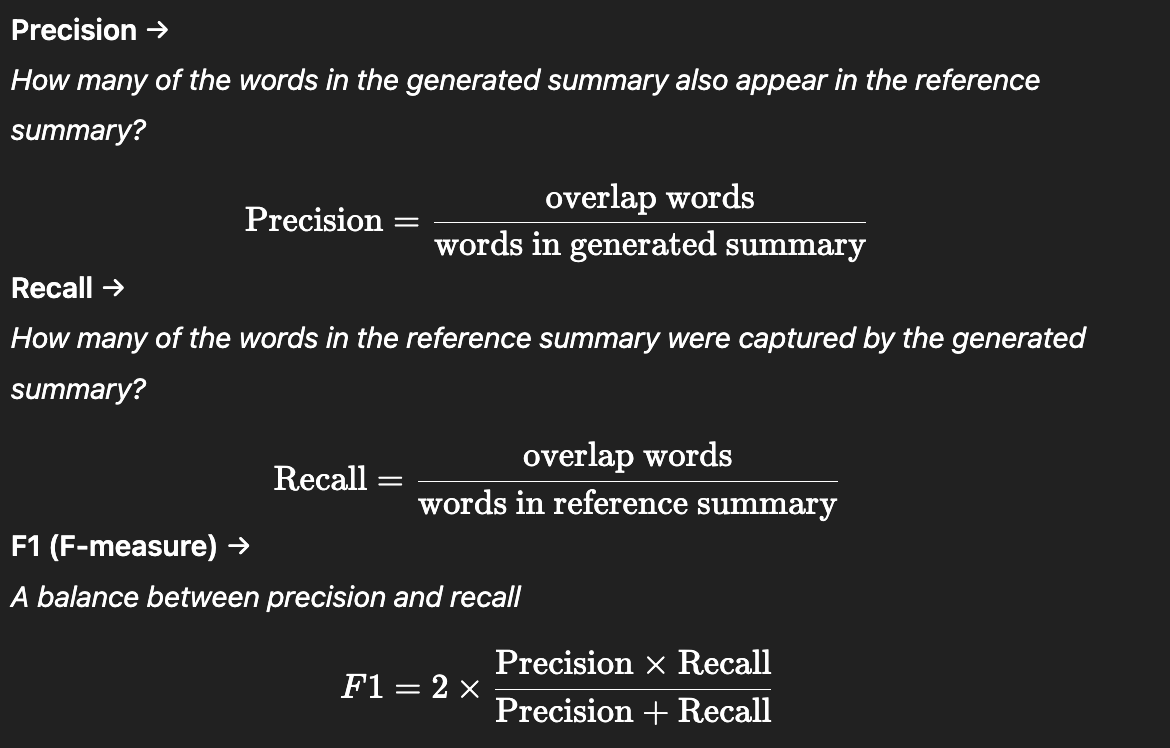

In [ ]:
scores["rouge1"].mid

Score(precision=0.92307692307692302, recall=1.0, fmeasure=0.92307692307692302)

In [ ]:
import nltk

nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:

nltk.download("punkt_tab")


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from nltk.tokenize import sent_tokenize


def three_sentence_summary(text):
    return "\n".join(sent_tokenize(text)[:3])


print(three_sentence_summary(books_dataset["train"][1]["review_body"]))

I grew up reading Koontz, and years ago, I stopped,convinced i had "outgrown" him.
Still,when a friend was looking for something suspenseful too read, I suggested Koontz.
She found Strangers.


In [ ]:
def evaluate_baseline(dataset, metric):
    summaries = [three_sentence_summary(text) for text in dataset["review_body"]]
    return metric.compute(predictions=summaries, references=dataset["review_title"])

In [ ]:
import pandas as pd

score = evaluate_baseline(books_dataset["validation"], rouge_score)

rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]
rouge_dict = {rn: round(score[rn] * 100, 2) for rn in rouge_names}

rouge_dict


{'rouge1': 16.739999999999998,
 'rouge2': 8.8000000000000007,
 'rougeL': 15.550000000000001,
 'rougeLsum': 15.93}

In [ ]:
from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from transformers import Seq2SeqTrainingArguments

batch_size = 8
num_train_epochs = 8
# Show the training loss with every epoch
logging_steps = len(tokenized_datasets["train"]) // batch_size
model_name = model_checkpoint.split("/")[-1]

args = Seq2SeqTrainingArguments(
    output_dir=f"{model_name}-finetuned-amazon-en-es",
    eval_strategy="epoch",
    learning_rate=5.6e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=num_train_epochs,
    predict_with_generate=True,
    logging_steps=logging_steps,
    report_to="none",  # ✅ disables W&B and all other trackers
    push_to_hub=False,
)

In [ ]:
import numpy as np
from nltk.tokenize import sent_tokenize

def compute_metrics(eval_pred):
    preds, labels = eval_pred

    # Some models (e.g., seq2seq) return logits instead of token IDs
    if isinstance(preds, tuple):
        preds = preds[0]

    # Convert logits -> token IDs if needed
    if preds.ndim == 3:
        preds = np.argmax(preds, axis=-1)

    # ⚠️ Replace -100 in labels with the tokenizer's pad token ID
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Now decode both safely
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # ROUGE expects newlines between sentences
    decoded_preds = ["\n".join(sent_tokenize(pred.strip())) for pred in decoded_preds]
    decoded_labels = ["\n".join(sent_tokenize(label.strip())) for label in decoded_labels]

    # Compute ROUGE
    result = rouge_score.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    # Extract median F1 scores
    result = {key: value.mid.fmeasure * 100 for key, value in result.items()}

    # Round nicely
    return {k: round(v, 4) for k, v in result.items()}


In [ ]:
"""from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)
"""

from transformers import DataCollatorForSeq2Seq
import torch

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

def clean_data_collator(features):
    batch = data_collator(features)
    # Replace -100 in labels with pad_token_id (usually 0)
    batch["labels"] = torch.where(batch["labels"] == -100, torch.tensor(tokenizer.pad_token_id), batch["labels"])
    return batch


In [ ]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 9672
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 245
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 238
    })
})

In [ ]:
"""tokenized_datasets = tokenized_datasets.remove_columns(
    books_dataset["train"].column_names
)"""
# ✅ Safe version — removes only if those columns exist
columns_to_remove = [col for col in books_dataset["train"].column_names if col in tokenized_datasets["train"].column_names]
tokenized_datasets = tokenized_datasets.remove_columns(columns_to_remove)

print("Removed:", columns_to_remove)


Removed: []


In [ ]:
features = [tokenized_datasets["train"][i] for i in range(2)]
data_collator(features)

{'input_ids': tensor([[   653,   1957,   1314,    261,   2757,   1280,    435,    259,  29166,
            263,    269,    774,   5547,      1,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              0,      0,      0,      0,      0,      0,      0,      0,      0,
              

In [ ]:
from transformers import Seq2SeqTrainer
import os
os.environ["WANDB_DISABLED"] = "true"

trainer = Seq2SeqTrainer(
    model,
    args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

In [ ]:
"""try:
    trainer.train()

except OverflowError as e:
    print("\n🚨 OverflowError detected!")
    print("Error message:", e)

    # Try to isolate bad predictions or labels if they exist
    print("\n🔍 Running one evaluation step manually to inspect...")
    try:
        eval_output = trainer.predict(tokenized_datasets["validation"])
        print("✅ Prediction step completed successfully.")
    except Exception as eval_err:
        print("❌ Error during evaluation:", eval_err)

    # Optionally inspect the first few input IDs
    sample = tokenized_datasets["validation"][0]
    print("\nExample input IDs:", sample["input_ids"][:50])
    print("Min ID:", min(sample["input_ids"]))
    print("Max ID:", max(sample["input_ids"]))
    print("Tokenizer vocab size:", trainer.tokenizer.vocab_size)

except Exception as e:
    print("\n❌ Other Exception caught:", e)"""


trainer.train()


Epoch,Training Loss,Validation Loss


AttributeError: 'numpy.float64' object has no attribute 'mid'

In [ ]:
import torch, numpy as np

with torch.no_grad():
    sample_batch = tokenized_datasets["validation"][:2]
    input_ids = torch.tensor(sample_batch["input_ids"]).to(model.device)
    outputs = model(input_ids=input_ids)
    logits = outputs.logits
    print("Logits shape:", logits.shape)
    preds = torch.argmax(logits, dim=-1)
    print("Max predicted token ID:", preds.max().item())
    print("Tokenizer vocab size:", tokenizer.vocab_size)


trainer.evaluate()

In [ ]:
tokenized_datasets.set_format("torch")

In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

In [ ]:
from torch.utils.data import DataLoader

batch_size = 8
train_dataloader = DataLoader(
    tokenized_datasets["train"],
    shuffle=True,
    collate_fn=data_collator,
    batch_size=batch_size,
)
eval_dataloader = DataLoader(
    tokenized_datasets["validation"], collate_fn=data_collator, batch_size=batch_size
)

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
from accelerate import Accelerator

accelerator = Accelerator()
model, optimizer, train_dataloader, eval_dataloader = accelerator.prepare(
    model, optimizer, train_dataloader, eval_dataloader
)

In [ ]:
from transformers import get_scheduler

num_train_epochs = 10
num_update_steps_per_epoch = len(train_dataloader)
num_training_steps = num_train_epochs * num_update_steps_per_epoch

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

In [ ]:
def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [label.strip() for label in labels]

    # ROUGE expects a newline after each sentence
    preds = ["\n".join(nltk.sent_tokenize(pred)) for pred in preds]
    labels = ["\n".join(nltk.sent_tokenize(label)) for label in labels]

    return preds, labels

In [ ]:
from huggingface_hub import get_full_repo_name

model_name = "test-bert-finetuned-squad-accelerate"
repo_name = get_full_repo_name(model_name)
repo_name

In [ ]:
from huggingface_hub import Repository

output_dir = "results-mt5-finetuned-squad-accelerate"
repo = Repository(output_dir, clone_from=repo_name)

In [ ]:
from tqdm.auto import tqdm
import torch
import numpy as np

progress_bar = tqdm(range(num_training_steps))

for epoch in range(num_train_epochs):
    # Training
    model.train()
    for step, batch in enumerate(train_dataloader):
        outputs = model(**batch)
        loss = outputs.loss
        accelerator.backward(loss)

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

    # Evaluation
    model.eval()
    for step, batch in enumerate(eval_dataloader):
        with torch.no_grad():
            generated_tokens = accelerator.unwrap_model(model).generate(
                batch["input_ids"],
                attention_mask=batch["attention_mask"],
            )

            generated_tokens = accelerator.pad_across_processes(
                generated_tokens, dim=1, pad_index=tokenizer.pad_token_id
            )
            labels = batch["labels"]

            # If we did not pad to max length, we need to pad the labels too
            labels = accelerator.pad_across_processes(
                batch["labels"], dim=1, pad_index=tokenizer.pad_token_id
            )

            generated_tokens = accelerator.gather(generated_tokens).cpu().numpy()
            labels = accelerator.gather(labels).cpu().numpy()

            # Ensure generated tokens are within vocab size before decoding
            generated_tokens = np.where(generated_tokens < tokenizer.vocab_size, generated_tokens, tokenizer.pad_token_id)
            generated_tokens = np.where(generated_tokens >= 0, generated_tokens, tokenizer.pad_token_id)

            # Replace -100 in the labels as we can't decode them
            labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
            if isinstance(generated_tokens, tuple):
                generated_tokens = generated_tokens[0]
            decoded_preds = tokenizer.batch_decode(
                generated_tokens, skip_special_tokens=True
            )
            decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

            decoded_preds, decoded_labels = postprocess_text(
                decoded_preds, decoded_labels
            )

            rouge_score.add_batch(predictions=decoded_preds, references=decoded_labels)

    # Compute metrics
    result = rouge_score.compute()
    # Extract the median ROUGE scores
    result = {key: value.mid.fmeasure * 100 for key, value in result.items()}
    result = {k: round(v, 4) for k, v in result.items()}
    print(f"Epoch {epoch}:", result)

    # Save and upload
    accelerator.wait_for_everyone()
    unwrapped_model = accelerator.unwrap_model(model)
    unwrapped_model.save_pretrained(output_dir, save_function=accelerator.save)
    if accelerator.is_main_process:
        tokenizer.save_pretrained(output_dir)
        repo.push_to_hub(
            commit_message=f"Training in progress epoch {epoch}", blocking=False
        )

In [ ]:
from transformers import pipeline

hub_model_id = "huggingface-course/mt5-small-finetuned-amazon-en-es"
summarizer = pipeline("summarization", model=hub_model_id)

In [ ]:
def print_summary(idx):
    review = books_dataset["test"][idx]["review_body"]
    title = books_dataset["test"][idx]["review_title"]
    summary = summarizer(books_dataset["test"][idx]["review_body"])[0]["summary_text"]
    print(f"'>>> Review: {review}'")
    print(f"\n'>>> Title: {title}'")
    print(f"\n'>>> Summary: {summary}'")

In [ ]:
print_summary(100)

In [ ]:
print_summary(0)